<a href="https://colab.research.google.com/github/Raajarapu/DS_ML_DEVOPS_AWS/blob/main/DSMLDEVCLOUD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd

In [4]:
df = pd.read_csv("transactions.csv")

In [5]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nDataset info:")
df.info()

Rows: 100
Columns: 5

Column names:
['transaction_id', 'amount', 'hour', 'num_tx_past_day', 'is_fraud']

Data types:
transaction_id      object
amount             float64
hour                 int64
num_tx_past_day      int64
is_fraud             int64
dtype: object

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   transaction_id   100 non-null    object 
 1   amount           100 non-null    float64
 2   hour             100 non-null    int64  
 3   num_tx_past_day  100 non-null    int64  
 4   is_fraud         100 non-null    int64  
dtypes: float64(1), int64(3), object(1)
memory usage: 4.0+ KB


In [6]:
df.isnull().sum()

,0
transaction_id,0
amount,0
hour,0
num_tx_past_day,0
is_fraud,0


In [7]:
df.describe()

,amount,hour,num_tx_past_day,is_fraud
count,100.000000,100.000000,100.000000,100.000000
mean,955.237300,12.060000,3.840000,0.260000
std,1385.467058,6.060003,2.669393,0.440844
min,15.750000,0.000000,1.000000,0.000000
25%,61.625000,9.000000,2.000000,0.000000
50%,187.500000,12.500000,3.000000,0.000000
75%,1775.000000,16.000000,5.250000,1.000000
max,4800.000000,23.000000,11.000000,1.000000


In [8]:
df[["amount", "hour", "num_tx_past_day"]].describe()

,amount,hour,num_tx_past_day
count,100.000000,100.000000,100.000000
mean,955.237300,12.060000,3.840000
std,1385.467058,6.060003,2.669393
min,15.750000,0.000000,1.000000
25%,61.625000,9.000000,2.000000
50%,187.500000,12.500000,3.000000
75%,1775.000000,16.000000,5.250000
max,4800.000000,23.000000,11.000000


In [9]:
df["is_fraud"].value_counts()

,count
is_fraud,
0,74
1,26


In [10]:
df["is_fraud"].value_counts(normalize=True) * 100

,proportion
is_fraud,
0,74.0
1,26.0


In [11]:
df.groupby("is_fraud")["amount"].agg(
    ["count", "mean", "median", "min", "max"]
)

,count,mean,median,min,max
is_fraud,,,,,
0,74,186.131486,107.5,15.75,1050.0
1,26,3144.230769,3125.0,1750.00,4800.0


In [12]:
df.groupby("is_fraud")["hour"].mean()

,hour
is_fraud,
0,12.662162
1,10.346154


In [13]:
df.groupby("is_fraud")["num_tx_past_day"].agg(
    ["mean", "median", "min", "max"]
)

,mean,median,min,max
is_fraud,,,,
0,2.445946,2.0,1,5
1,7.807692,8.0,5,11


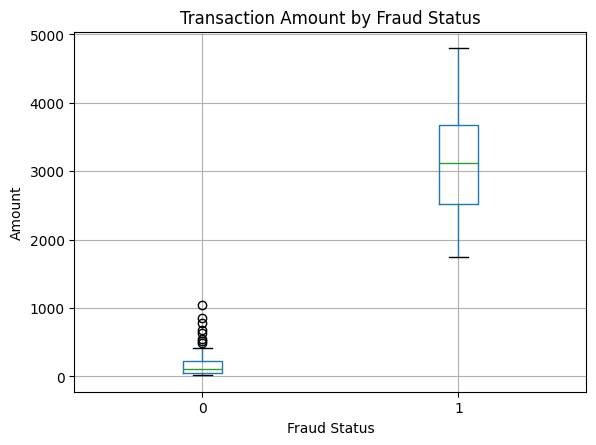

In [14]:
import matplotlib.pyplot as plt

df.boxplot(column="amount", by="is_fraud")
plt.title("Transaction Amount by Fraud Status")
plt.suptitle("")
plt.xlabel("Fraud Status")
plt.ylabel("Amount")
plt.show()

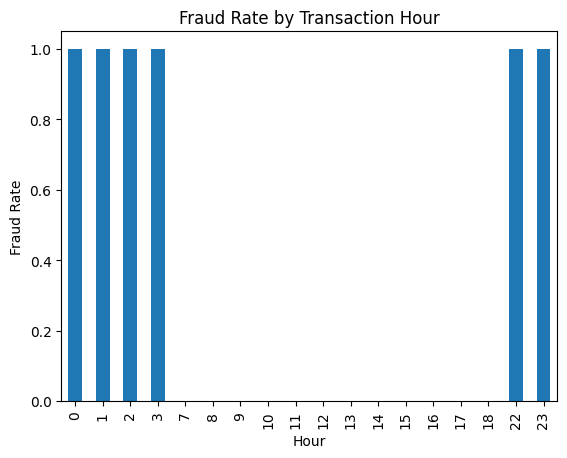

In [15]:
df.groupby("hour")["is_fraud"].mean().plot(kind="bar")
plt.title("Fraud Rate by Transaction Hour")
plt.xlabel("Hour")
plt.ylabel("Fraud Rate")
plt.show()

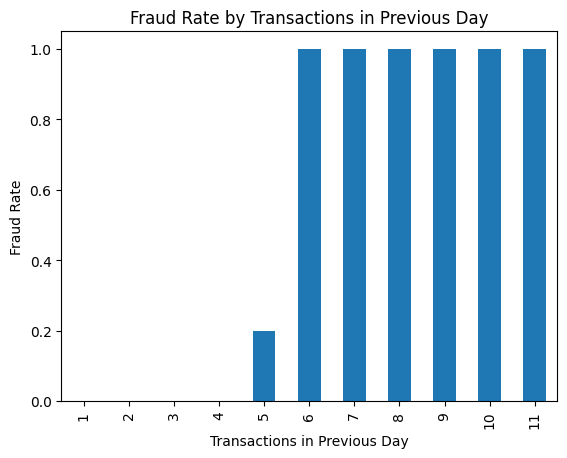

In [16]:
df.groupby("num_tx_past_day")["is_fraud"].mean().plot(kind="bar")
plt.title("Fraud Rate by Transactions in Previous Day")
plt.xlabel("Transactions in Previous Day")
plt.ylabel("Fraud Rate")
plt.show()

In [19]:
X = df.drop(columns=["transaction_id", "is_fraud"])
y = df["is_fraud"]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

Features:
['amount', 'hour', 'num_tx_past_day']

Target:
is_fraud


In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training samples: 80
Testing samples: 20

Training target distribution:
is_fraud
0    59
1    21
Name: count, dtype: int64

Testing target distribution:
is_fraud
0    15
1     5
Name: count, dtype: int64


In [21]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=5, random_state=42)

In [22]:
y_pred = model.predict(X_test)

print("Predictions:")
print(y_pred)

Predictions:
[0 1 0 1 0 0 0 1 0 0 0 1 0 0 0 0 1 0 0 0]


In [23]:
y_proba = model.predict_proba(X_test)[:, 1]

print("Fraud probabilities:")
print(y_proba)

Fraud probabilities:
[0.02 1.   0.   0.97 0.   0.   0.   1.   0.   0.   0.   1.   0.   0.
 0.   0.   0.99 0.   0.   0.  ]


In [24]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1 Score : 1.0000


In [25]:
print(classification_report(y_test, y_pred, zero_division=0))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      1.00      1.00         5

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



In [26]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[15  0]
 [ 0  5]]


In [27]:
feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

feature_importance

,feature,importance
0,amount,0.447969
2,num_tx_past_day,0.320083
1,hour,0.231948


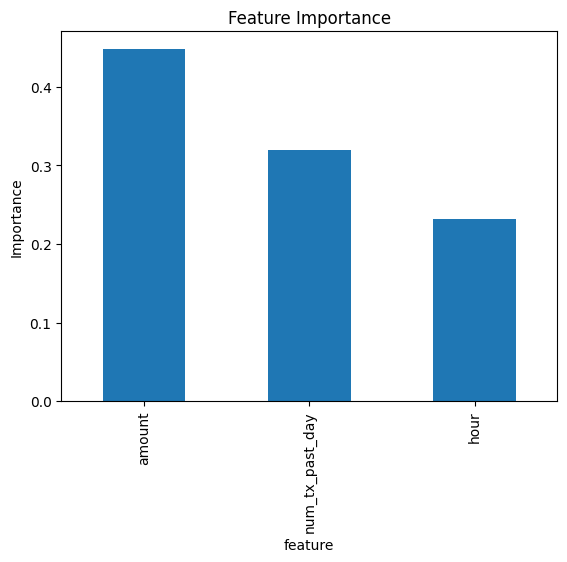

In [28]:
feature_importance.plot(
    x="feature",
    y="importance",
    kind="bar",
    legend=False,
    title="Feature Importance"
)

plt.ylabel("Importance")
plt.show()

In [29]:
new_transaction = pd.DataFrame({
    "amount": [3200],
    "hour": [23],
    "num_tx_past_day": [5]
})

prediction = model.predict(new_transaction)[0]
probability = model.predict_proba(new_transaction)[0, 1]

print("Prediction:", int(prediction))
print(f"Fraud probability: {probability:.4f}")

Prediction: 1
Fraud probability: 0.8100


In [30]:
new_transaction = pd.DataFrame({
    "amount": [25.5],
    "hour": [10],
    "num_tx_past_day": [1]
})

prediction = model.predict(new_transaction)[0]
probability = model.predict_proba(new_transaction)[0, 1]

print("Prediction:", int(prediction))
print(f"Fraud probability: {probability:.4f}")

Prediction: 0
Fraud probability: 0.0000


In [31]:
import joblib

joblib.dump(model, "fraud_model.pkl")

print("Model saved successfully.")

Model saved successfully.


In [32]:
import os

print(os.path.exists("fraud_model.pkl"))
print(os.path.getsize("fraud_model.pkl"), "bytes")

True
87017 bytes


In [33]:
loaded_model = joblib.load("fraud_model.pkl")

test_transaction = pd.DataFrame({
    "amount": [3200],
    "hour": [23],
    "num_tx_past_day": [5]
})

prediction = loaded_model.predict(test_transaction)[0]

print("Loaded model prediction:", int(prediction))

Loaded model prediction: 1


In [34]:
import json

metadata = {
    "model_name": "fraud_detector",
    "model_type": "RandomForestClassifier",
    "features": [
        "amount",
        "hour",
        "num_tx_past_day"
    ],
    "target": "is_fraud",
    "random_state": 42,
    "n_estimators": 100,
    "metrics": {
        "accuracy": float(accuracy),
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1)
    }
}

with open("model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=4)

print(json.dumps(metadata, indent=4))

{
    "model_name": "fraud_detector",
    "model_type": "RandomForestClassifier",
    "features": [
        "amount",
        "hour",
        "num_tx_past_day"
    ],
    "target": "is_fraud",
    "random_state": 42,
    "n_estimators": 100,
    "metrics": {
        "accuracy": 1.0,
        "precision": 1.0,
        "recall": 1.0,
        "f1": 1.0
    }
}
